<a href="https://colab.research.google.com/github/mosesdorri-gif/Projcet-2/blob/main/Smoking_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **IMPORTS**

In [211]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [212]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/insurance.csv')
df['bmi'] = df['bmi'].round()

### EXPLORATORY DATA ANALYSIS

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [214]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,28.0,0,yes,southwest,16884.92400
1,18,male,34.0,1,no,southeast,1725.55230
2,28,male,33.0,3,no,southeast,4449.46200
3,33,male,23.0,0,no,northwest,21984.47061
4,32,male,29.0,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.54830
1334,18,female,32.0,0,no,northeast,2205.98080
1335,18,female,37.0,0,no,southeast,1629.83350
1336,21,female,26.0,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

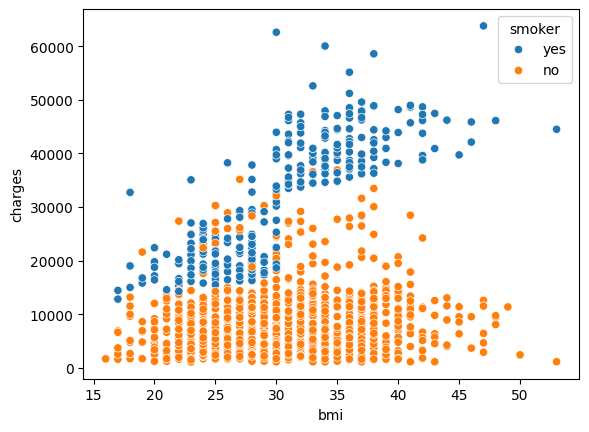

In [215]:
sns.scatterplot(x = df['bmi'] , y = df['charges'], hue = df['smoker'])

<Axes: xlabel='smoker', ylabel='count'>

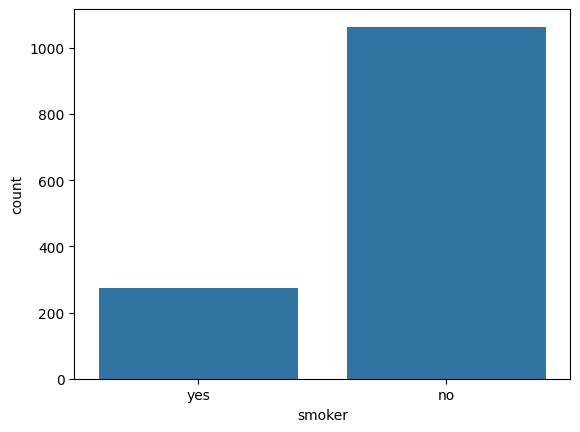

In [216]:
sns.countplot( x  = df['smoker'] )

In [217]:
df.replace({'female':1, 'male':0, 'yes':1,'no':0}, inplace = True)


/tmp/ipykernel_4275/459568323.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'female':1, 'male':0, 'yes':1,'no':0}, inplace = True)


<Axes: >

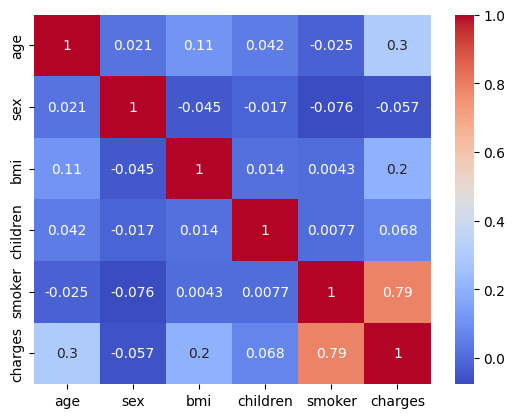

In [218]:
sns.heatmap(df.drop('region', axis = 1).corr() ,annot=  True,cmap = 'coolwarm')

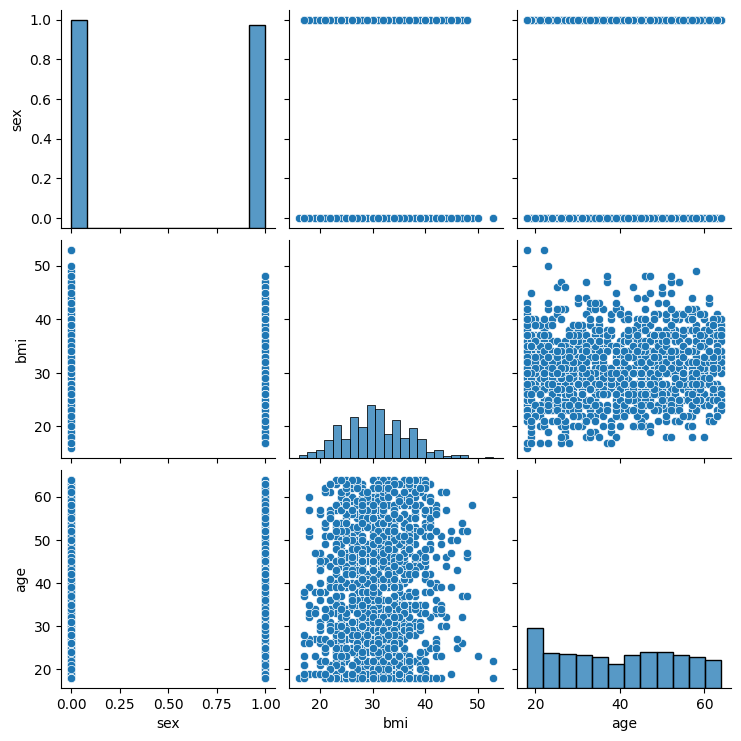

In [219]:
sns.pairplot( data = df[['sex','bmi','age']])


the data seems to be clean for the most part. I'd assume this dataset is for health insurance as BMI matters. Maybe we can see some interesting information with a simple question: can we classify someone as a smoker given their age, sex,bmi, and insurance charge. Well we can try! let's use logistic regression.

### FEATURE SCALING

our dependent variable for this project will be the smoking category

In [220]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report


In [221]:
y = df['smoker']

In [222]:
X = df.drop(['smoker','region'], axis = 1)
y = df['smoker']

In [223]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)

In [224]:
scaler = StandardScaler()

In [225]:
X_train  = scaler.fit_transform(X_train)

In [226]:
X_test = scaler.transform(X_test)

# Model creation

In [227]:
from sklearn.model_selection import GridSearchCV
griddy = GridSearchCV(estimator=lr_model,param_grid=params,cv = 5,scoring='accuracy')

In [228]:
lr_model = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=10000)

In [229]:
C = np.logspace(-1,1,100)
elasticnet = [0,1,0.1,10]
l1_ratio = [0,0.1,0.25,0.75,0.85,0.99]

In [230]:
params = {'C':C, 'l1_ratio': l1_ratio,}

In [234]:
griddy.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=10000, penalty='elasticnet',
                                          solver='saga'),
             param_grid={'C': array([ 0.1       ,  0.10476158,  0.10974988,  0.1149757 ,  0.12045035,
        0.12618569,  0.13219411,  0.13848864,  0.14508288,  0.15199111,
        0.15922828,  0.16681005,  0.17475284,  0.18307383,  0.19179103,
        0.2009233 ,  0.21049041,  0.22051307,  0.23101297,  0.24201283,
        0.25353645,  0.26560...
        2.59502421,  2.71858824,  2.84803587,  2.98364724,  3.12571585,
        3.27454916,  3.43046929,  3.59381366,  3.76493581,  3.94420606,
        4.1320124 ,  4.32876128,  4.53487851,  4.75081016,  4.97702356,
        5.21400829,  5.46227722,  5.72236766,  5.9948425 ,  6.28029144,
        6.57933225,  6.8926121 ,  7.22080902,  7.56463328,  7.92482898,
        8.30217568,  8.69749003,  9.11162756,  9.54548457, 10.        ]),
                         'l1_ratio': [0, 0.1, 0.25, 0.75, 0.85, 0.99]},
             scoring='accuracy')

In [235]:
y_pred = griddy.predict(X_test)

In [236]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       159
           1       0.90      0.90      0.90        42

    accuracy                           0.96       201
   macro avg       0.94      0.94      0.94       201
weighted avg       0.96      0.96      0.96       201



In [237]:
from sklearn.metrics import roc_curve

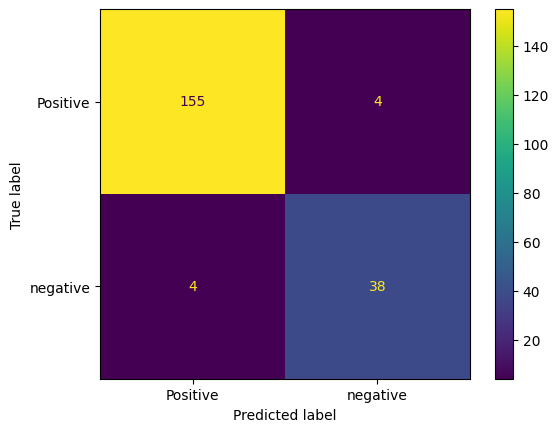

In [238]:
confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Positive','negative'],
    cmap=plt.cm.viridis)





In [239]:
from sklearn.metrics import RocCurveDisplay

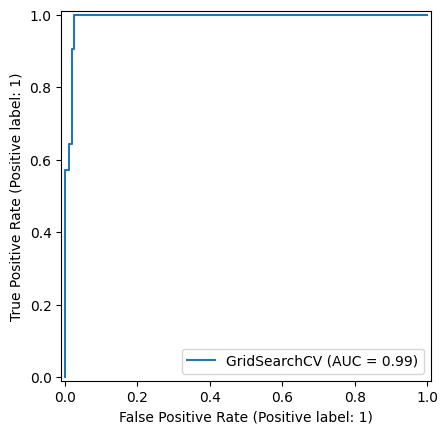

In [240]:
RocCurveDisplay.from_estimator(griddy, X_test, y_test)